# Dataset EDA and Risk Feature Overview

This notebook summarizes the SMS Spam Collection dataset and the explainability-oriented risk features used by the benchmark outputs. It is analysis-only: no model training, API calls, or `.env` loading.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either repo-root or notebooks/ execution."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "SMSSpamCollection").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root containing data/SMSSpamCollection and src/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "SMSSpamCollection"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
print(f"Project root: {PROJECT_ROOT.relative_to(PROJECT_ROOT)} (resolved internally)")

Project root: . (resolved internally)


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.classical_baselines import load_sms_data
from src.features import extract_risk_features

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

## Load Dataset

The dataset is loaded from `data/SMSSpamCollection` through the project utility, keeping notebook logic thin and consistent with `src/`.

In [3]:
df = load_sms_data(DATA_PATH)
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
display(df.head())

Rows: 5,574
Columns: ['label', 'text']


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


The raw dataset has one row per SMS with a normalized label (`ham` or `spam`) and the message text. The notebooks use this file as read-only input.

## Label Distribution

A quick class balance check helps interpret later accuracy and recall results, especially because spam is the minority class.

,label,count,share
0,ham,4827,0.865985
1,spam,747,0.134015


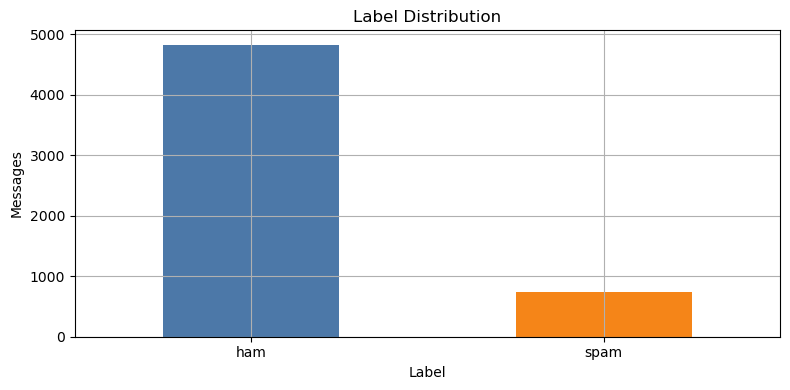

In [4]:
label_counts = df["label"].value_counts().rename_axis("label").reset_index(name="count")
label_counts["share"] = label_counts["count"] / label_counts["count"].sum()
display(label_counts)

ax = label_counts.plot(kind="bar", x="label", y="count", legend=False, color=["#4C78A8", "#F58518"])
ax.set_title("Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Messages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Ham messages dominate the corpus, so spam recall is a more revealing safety metric than accuracy alone.

## Message Length by Label

Length statistics are useful because spam often includes longer promotional text, links, phone numbers, or call-to-action phrasing.

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4827.0,71.47,58.33,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.68,28.87,13.0,133.0,149.0,157.0,223.0


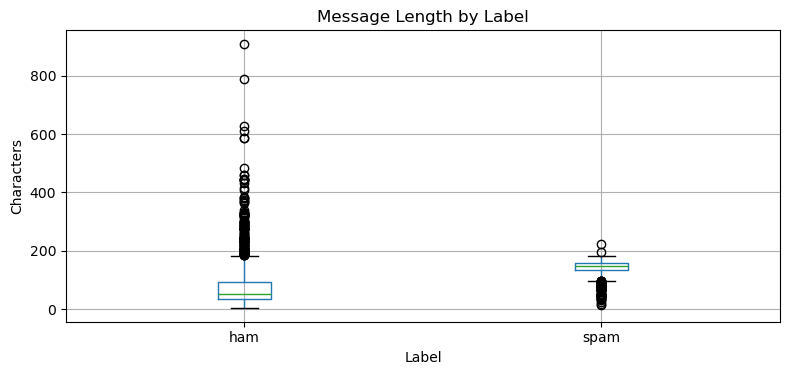

In [5]:
df_len = df.assign(message_length=df["text"].str.len())
length_stats = df_len.groupby("label")["message_length"].describe().round(2)
display(length_stats)

ax = df_len.boxplot(column="message_length", by="label", grid=True)
ax.set_title("Message Length by Label")
ax.set_xlabel("Label")
ax.set_ylabel("Characters")
plt.suptitle("")
plt.tight_layout()
plt.show()

The length distribution provides context for the engineered `message_length` risk feature, but length alone should not be treated as a rule.

## Sample Messages

Small samples help sanity-check the text format without dumping the full dataset.

In [6]:
for label in ["ham", "spam"]:
    print()
    print(f"Sample {label.upper()} messages")
    sample = df[df["label"] == label].sample(n=5, random_state=42)[["label", "text"]]
    display(sample.reset_index(drop=True))


Sample HAM messages


,label,text
0,ham,"Dear,Me at cherthala.in case u r coming cochin..."
1,ham,Ok. I only ask abt e movie. U wan ktv oso?
2,ham,Convey my regards to him
3,ham,"Hi Jon, Pete here, Ive bin 2 Spain recently & ..."
4,ham,I had askd u a question some hours before. Its...



Sample SPAM messages


,label,text
0,spam,Summers finally here! Fancy a chat or flirt wi...
1,spam,This is the 2nd time we have tried 2 contact u...
2,spam,Get ur 1st RINGTONE FREE NOW! Reply to this ms...
3,spam,Ur cash-balance is currently 500 pounds - to m...
4,spam,Last Chance! Claim ur £150 worth of discount v...


The examples show why both lexical cues and context matter: some ham messages contain informal commands, while spam can include reward, urgency, or contact instructions.

## Risk Feature Extraction

The project logs lightweight risk/explainability features alongside predictions. These features are descriptive; they are not hard-coded classification rules.

In [7]:
risk_df = pd.DataFrame([extract_risk_features(text) for text in df["text"]])
eda_df = pd.concat([df.reset_index(drop=True), risk_df], axis=1)
print(f"Risk feature columns: {list(risk_df.columns)}")
display(eda_df.head())

Risk feature columns: ['has_url', 'has_phone', 'has_currency', 'has_urgent_word', 'has_prize_word', 'has_call_instr', 'uppercase_ratio', 'exclamation_count', 'message_length']


,label,text,has_url,has_phone,has_currency,has_urgent_word,has_prize_word,has_call_instr,uppercase_ratio,exclamation_count,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",False,False,False,False,False,False,0.0361,0,111
1,ham,Ok lar... Joking wif u oni...,False,False,False,False,False,False,0.1111,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,False,True,False,False,True,True,0.1031,0,155
3,ham,U dun say so early hor... U c already then say...,False,False,False,False,False,False,0.0606,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",False,False,False,False,False,False,0.0426,0,61


## Risk Feature Prevalence by Label

Boolean feature prevalence and numeric feature averages reveal which cues are more common in spam versus ham.

label,ham,spam
has_url,0.0029,0.1861
has_phone,0.0021,0.8273
has_currency,0.0068,0.3976
has_urgent_word,0.0912,0.3641
has_prize_word,0.0215,0.5060
has_call_instr,0.0970,0.8434
uppercase_ratio,0.0790,0.1673
exclamation_count,0.1765,0.7296
message_length,71.4719,138.6760


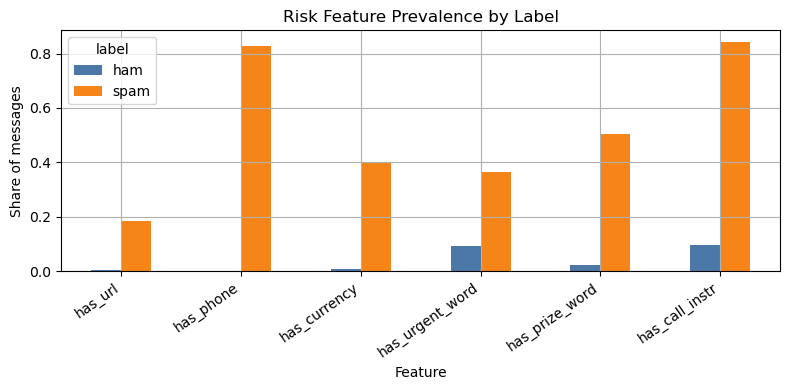

In [8]:
risk_cols = [
    "has_url",
    "has_phone",
    "has_currency",
    "has_urgent_word",
    "has_prize_word",
    "has_call_instr",
    "uppercase_ratio",
    "exclamation_count",
    "message_length",
]
prevalence = eda_df.groupby("label")[risk_cols].mean().T.round(4)
display(prevalence)

plot_cols = ["has_url", "has_phone", "has_currency", "has_urgent_word", "has_prize_word", "has_call_instr"]
ax = prevalence.loc[plot_cols].plot(kind="bar", color=["#4C78A8", "#F58518"])
ax.set_title("Risk Feature Prevalence by Label")
ax.set_xlabel("Feature")
ax.set_ylabel("Share of messages")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Spam messages are expected to show higher rates for prize, currency, urgency, URL, phone, and call/reply cues. These features support later error analysis by explaining what each model missed or handled well.